# Финальный проект. Телеком

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах.

**Ваша задача** — обучить на этих данных модель для прогноза оттока клиентов.


**Описание услуг**

Оператор предоставляет два основных типа услуг:
1. Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
2. Интернет. Подключение бывает двух типов: через телефонную линию DSL (англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (англ. fiber optic).

Также абонентам доступен ряд услуг:
- Интернет-безопасность: антивирус (Device Protection) и блокировка опасных сайтов (Online Security);
- Выделенная линия технической поддержки (Tech Support);
Облачное хранилище файлов для резервного копирования данных (Online Backup);
- Стриминговое телевидение (Streaming TV) и каталог фильмов (Streaming Movies).

За услуги клиенты могут платить ежемесячно или раз в 1–2 года. Доступны различные способы расчёта и возможность получить электронный чек.

**Описание данных**
Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:
- **contract** — информация о договорах;
- **personal** — персональные данные клиентов;
- **internet** — информация об интернет-услугах;
- **phone** — информация об услугах телефонии.

**Таблица contract**
- `customerID` — ID абонента;
- `BeginDate` — дата начала действия договора;
- `EndDate` — дата окончания действия договора;
- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `PaperlessBilling` — электронный расчётный лист;
- `PaymentMethod` — тип платежа;
- `MonthlyCharges` — расходы за месяц;
- `TotalCharges` — общие расходы абонента.

**Таблица personal**
- `customerID` — ID пользователя;
- `gender` — пол;
- `SeniorCitizen` — является ли абонент пенсионером;
- `Partner` — есть ли у абонента супруг или супруга;
- `Dependents` — есть ли у абонента дети.

**Таблица internet**
- `customerID` — ID пользователя;
- `InternetService` — тип подключения;
- `OnlineSecurity` — блокировка опасных сайтов;
- `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
- `DeviceProtection` — антивирус;
- `TechSupport` — выделенная линия технической поддержки;
- `StreamingTV` — стриминговое телевидение;
- `StreamingMovies` — каталог фильмов.

**Таблица phone**
- `customerID` — ID пользователя;
- `MultipleLines` — подключение телефона к нескольким линиям одновременно.

Информация о договорах актуальна на 1 февраля 2020.

**Содержание работы:**

1. Загрузка данных
2. Предобработка данных
3. Исследовательский анализ
4. Обучение модели
5. Тестирование и демонстрация работы модели
6. Выводы

## Загрузка даннных

In [3]:
#!pip install -U numpy
#!pip install --force-reinstall --no-cache-dir catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 27.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 100.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 171.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 107.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 242.5 MB/s eta 0:00:00
   

In [77]:
# Импорты
# Стандартные библиотеки
import os
import random
from itertools import product

# Научные библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SQL и подключение к базе
from sqlalchemy import create_engine

# Предобработка и моделирование
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Модели
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier, Pool
from imblearn.over_sampling import SMOTE

# Подбор параметров
from scipy.stats import randint, uniform

# Сохранение / загрузка
import joblib


In [55]:
# Константы
RANDOM_STATE = 260325

In [3]:
!wget https://code.s3.yandex.net/data-scientist/ds-plus-final.db

--2025-03-27 18:14:59--  https://code.s3.yandex.net/data-scientist/ds-plus-final.db
Resolving code.s3.yandex.net (code.s3.yandex.net)... 93.158.134.158, 2a02:6b8::2:158
Connecting to code.s3.yandex.net (code.s3.yandex.net)|93.158.134.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3588096 (3.4M) [application/octet-stream]
Saving to: ‘ds-plus-final.db’

ds-plus-final.db    100%[===================>]   3.42M  2.64MB/s    in 1.3s    

2025-03-27 18:15:01 (2.64 MB/s) - ‘ds-plus-final.db’ saved [3588096/3588096]



In [6]:
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

In [7]:
# Загрузка всех таблиц
tables = ['contract', 'personal', 'internet', 'phone']
dfs = {table: pd.read_sql(f'SELECT * FROM {table}', con=engine) for table in tables}

In [8]:
# Проверка загрузки всех таблиц из словаря dfs
for name, df in dfs.items():
    print(f"{name}: shape = {df.shape}")


contract: shape = (7043, 8)
personal: shape = (7043, 5)
internet: shape = (5517, 8)
phone: shape = (6361, 2)


In [9]:
# Выводим информацию о размере и первых строках каждой таблицы
for name, df in dfs.items():
    print(f'\n Таблица: {name} — размер: {df.shape}')
    display(df.head())
    display(df.info())


 Таблица: contract — размер: (7043, 8)


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   BeginDate         7043 non-null   object
 2   EndDate           7043 non-null   object
 3   Type              7043 non-null   object
 4   PaperlessBilling  7043 non-null   object
 5   PaymentMethod     7043 non-null   object
 6   MonthlyCharges    7043 non-null   object
 7   TotalCharges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB


None


 Таблица: personal — размер: (7043, 5)


...

None


 Таблица: phone — размер: (6361, 2)


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None

## Первичный EDA-анализ

**План:**

- Проверить пропуски и типы;

- Привести MonthlyCharges, TotalCharges, SeniorCitizen к нужным типам;

- Проверить, почему internet и phone меньше по размеру;

- Провести визуальный и числовой анализ распределений;

- Определить, какие признаки бинарные, категориальные, числовые;

- Выделить потенциальные аномалии.

In [10]:
# Приводим названия всех колонок к нижнему регистру и snake_case
for name, df in dfs.items():
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Приведение типов
dfs['contract']['monthlycharges'] = pd.to_numeric(dfs['contract']['monthlycharges'], errors='coerce')
dfs['contract']['totalcharges'] = pd.to_numeric(dfs['contract']['totalcharges'], errors='coerce')
dfs['personal']['seniorcitizen'] = dfs['personal']['seniorcitizen'].astype(int)

# Преобразуем 'No' в EndDate → NaN (то есть договор не расторгнут)
dfs['contract']['enddate'] = dfs['contract']['enddate'].replace('No', np.nan)

# Переименуем CustomerId в 'phone', чтобы совпадало
dfs['phone'] = dfs['phone'].rename(columns={'customerid': 'customerid'})

# Проверим количество пропусков
for name, df in dfs.items():
    print(f'\n{name.upper()} — пропуски:')
    display(df.isna().sum())


CONTRACT — пропуски:


,0
customerid,0
begindate,0
enddate,5942
type,0
paperlessbilling,0
paymentmethod,0
monthlycharges,0
totalcharges,11



PERSONAL — пропуски:


,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0



INTERNET — пропуски:


,0
customerid,0
internetservice,0
onlinesecurity,0
onlinebackup,0
deviceprotection,0
techsupport,0
streamingtv,0
streamingmovies,0



PHONE — пропуски:


,0
customerid,0
multiplelines,0


**Промежуточные выводы по первичному EDA-анализу**

**Таблица contract:**

- 5942 пропуска в enddate → значит 5942 клиента не ушли, а остальные (7043 - 5942 = 1101) — ушли.
Это и будет наша целевая переменная (is_churn).

- 11 пропусков в totalcharges — скорее всего, у новых клиентов, у которых monthlycharges > 0, но totalcharges ещё не накопились.

**Таблица personal:**

- Всё в порядке — без пропусков, признаки бинарные (yes / no), seniorcitizen — теперь int.

**Таблица internet:**

- 7043 - 5517 = 1526 клиентов не используют интернет, отсюда и отсутствие записей → при объединении будет NaN.

**Таблица phone**

- 7043 - 6361 = 682 клиента не используют телефонию, аналогично.

## Объединение таблиц

План:

1. Пропущенные строки (в internet, phone) сохраняем — для тех клиентов просто нет таких услуг.

2. После объединения — создадим is_churn = 1, если enddate заполнено.

3. Также посчитаем contract_duration = дата_сдачи - дата_начала (мы знаем, что данные на 01.02.2020).

In [11]:
# Объединение таблиц
df_full = dfs['contract'] \
    .merge(dfs['personal'], on='customerid', how='left') \
    .merge(dfs['internet'], on='customerid', how='left') \
    .merge(dfs['phone'], on='customerid', how='left')

In [12]:
# Создаём флаг оттока
df_full['is_churn'] = df_full['enddate'].notna().astype(int)

In [13]:
# Преобразуем даты
df_full['begindate'] = pd.to_datetime(df_full['begindate'])
df_full['enddate'] = pd.to_datetime(df_full['enddate'])

In [14]:
# Дата актуальности данных
reference_date = pd.to_datetime('2020-02-01')

In [15]:
# Длительность контракта в днях
df_full['contract_duration'] = (
    df_full['enddate'].fillna(reference_date) - df_full['begindate']
).dt.days

In [16]:
# Проверим
print(f'Форма итогового датафрейма: {df_full.shape}')
display(df_full.head())

Форма итогового датафрейма: (7043, 22)


,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,gender,seniorcitizen,...,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines,is_churn,contract_duration
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,Female,0,...,DSL,No,Yes,No,No,No,No,NaN,0,31
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,Male,0,...,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,...,DSL,Yes,Yes,No,No,No,No,No,0,123
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,Male,0,...,DSL,Yes,No,Yes,Yes,No,No,NaN,0,1371
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,...,Fiber optic,No,No,No,No,No,No,No,0,153


In [17]:
# 1. Заменим "No internet service" и "No phone service" на просто "No"
cols_to_fix = [
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies', 'multiplelines'
]

for col in cols_to_fix:
    df_full[col] = df_full[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# 2. Бинарные признаки: пользуется ли интернетом / телефонией
df_full['has_internet'] = df_full['internetservice'].apply(lambda x: 0 if pd.isna(x) or x == 'No' else 1)
df_full['has_phone'] = df_full['multiplelines'].apply(lambda x: 0 if pd.isna(x) or x == 'No' else 1)

# 3. Количество активных онлайн-сервисов
online_services = ['onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies']
df_full['num_online_services'] = df_full[online_services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# 4. Удалим строки с пропусками в totalcharges (всего 11 наблюдений)
df_full = df_full[df_full['totalcharges'].notna()].reset_index(drop=True)

# 5. Убедимся, что multiplelines теперь бинарный (Yes/No/NaN → обработаем позже)
print(f'Пропуски после обработки: \n{df_full.isna().sum()}')


Пропуски после обработки: 
customerid                0
begindate                 0
enddate                5931
type                      0
paperlessbilling          0
paymentmethod             0
monthlycharges            0
totalcharges              0
gender                    0
seniorcitizen             0
partner                   0
dependents                0
internetservice        1520
onlinesecurity         1520
onlinebackup           1520
deviceprotection       1520
techsupport            1520
streamingtv            1520
streamingmovies        1520
multiplelines           680
is_churn                  0
contract_duration         0
has_internet              0
has_phone                 0
num_online_services       0
dtype: int64


**Интерпретация пропусков:**

`enddate` — как и ожидалось, означает отсутствие оттока (живые клиенты);

`internetservice` и все связанные признаки — отсутствуют у 1520 клиентов, не подключавших интернет (оставим как есть);

`multiplelines` отсутствует у 680 клиентов, не пользовавшихся телефонией — аналогично.

Мы не будем заполнять эти пропуски — они логичны. Позже при кодировании категорий они будут обрабатываться как отдельные значения (NaN → No или категориальный код).

## EDA-анализ по объединенной таблице

План:
- Анализ баланса классов по is_churn;

- Анализ оттока по бинарным признакам (gender, partner, dependents, has_internet, has_phone);

- Анализ оттока по категориальным признакам (contract type, payment method, internetservice);

- Анализ числовых признаков: monthlycharges, totalcharges, contract_duration, num_online_services.



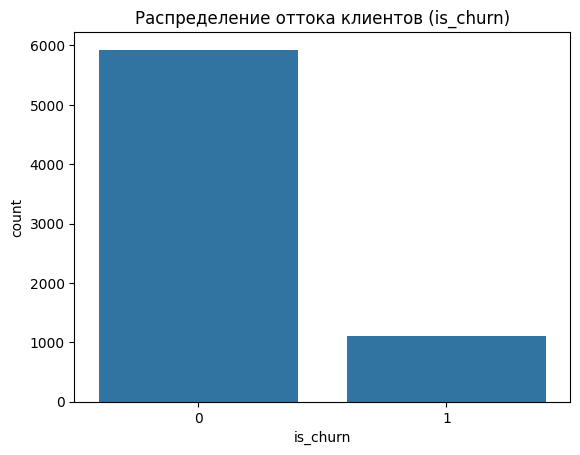

In [18]:
# 1. Баланс классов
sns.countplot(x='is_churn', data=df_full)
plt.title('Распределение оттока клиентов (is_churn)')
plt.show()

На гистограмме чётко видно, что классы несбалансированы: клиентов, которые не ушли (is_churn = 0), примерно в 5 раз больше, чем тех, кто ушёл (is_churn = 1).

**Это важно:**

Нужно будет учесть дисбаланс при обучении моделей (например, использовать class_weight='balanced', SMOTE, либо специальные алгоритмы как CatBoost/LightGBM, умеющие работать с дисбалансом);

Метрика accuracy не подойдёт — основной акцент будет на ROC-AUC, precision, recall.

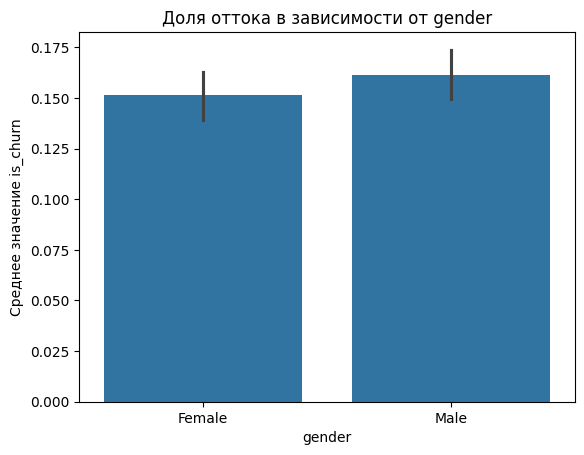

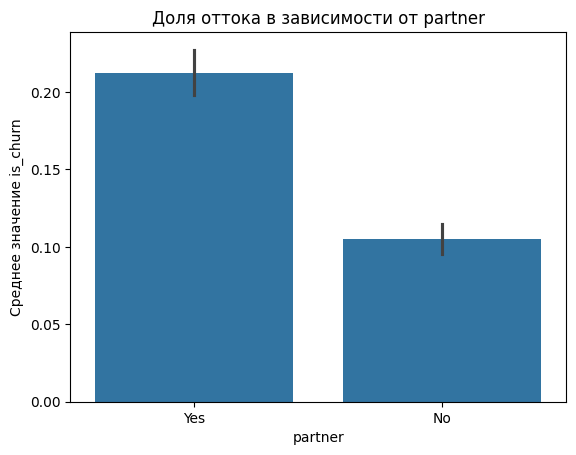

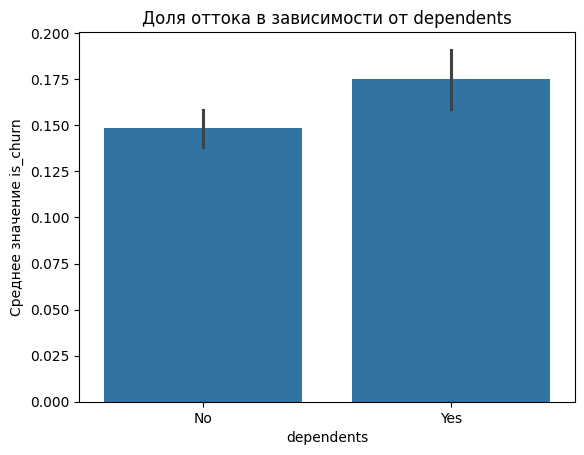

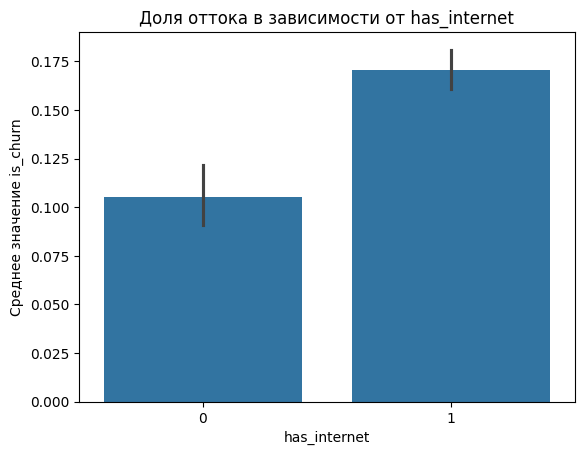

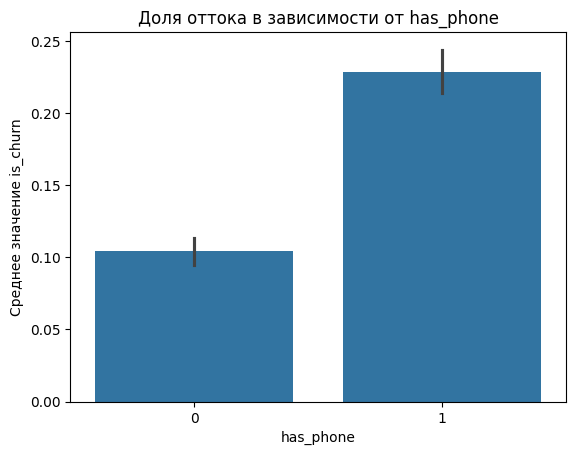

In [19]:
# 2. Отток по бинарным признакам
binary_cols = ['gender', 'partner', 'dependents', 'has_internet', 'has_phone']

for col in binary_cols:
    sns.barplot(x=col, y='is_churn', data=df_full)
    plt.title(f'Доля оттока в зависимости от {col}')
    plt.ylabel('Среднее значение is_churn')
    plt.show()


**has_phone:**

Отток среди пользователей телефонии значительно выше (около 23%), чем у тех, кто ею не пользуется (около 10%);

Возможно, пользователи с телефонией — более мобильные / чувствительны к цене.

**has_internet:**

Аналогично — отток среди пользователей интернета выше;

Логично: если человек не пользуется интернетом, значит, связь ему важна только для базовых нужд — менее вероятен отток.

**dependents:**

Небольшая разница — наличие иждивенцев связано с немного меньшей вероятностью оттока (что ожидаемо — стабильные семьи меньше склонны менять провайдера).

**partner:**

Обратная связь: с партнёром — отток выше, без партнёра — ниже. Необычно, но может быть связано с жизненным циклом семьи или количеством альтернатив.

**gender:**

Различие минимально: пол не является значимым предиктором оттока.

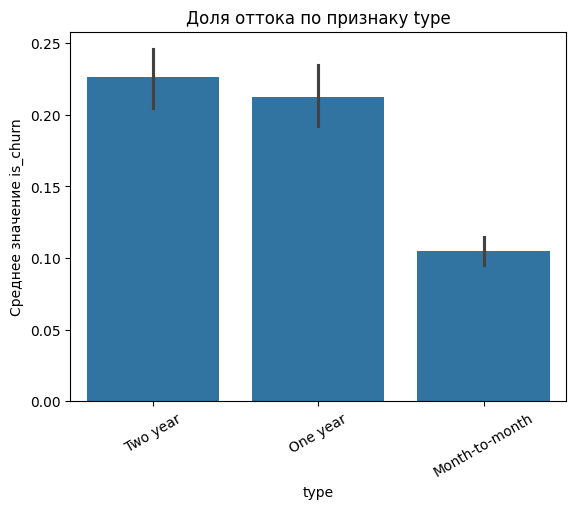

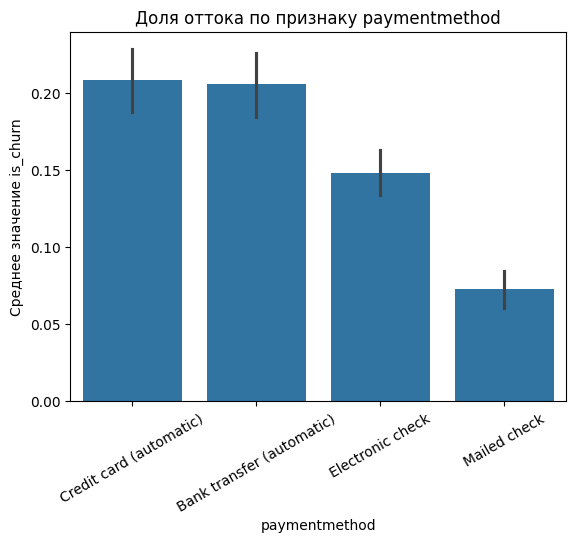

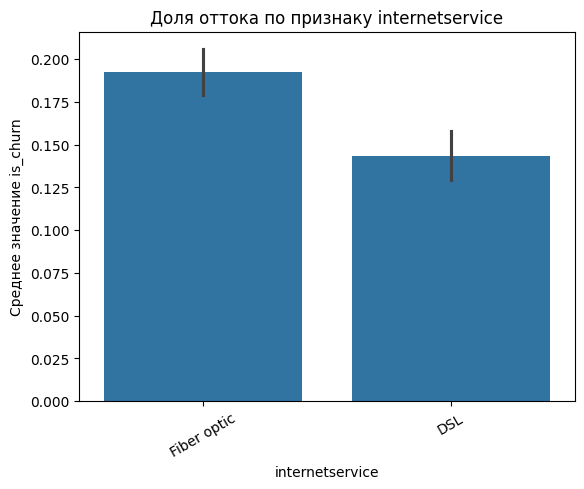

In [20]:
# Отток по категориальным признакам
cat_cols = ['type', 'paymentmethod', 'internetservice']

for col in cat_cols:
    # Вычислим порядок категорий по доле оттока
    order = df_full.groupby(col)['is_churn'].mean().sort_values(ascending=False).index

    # Построим график
    sns.barplot(x=col, y='is_churn', data=df_full, order=order)
    plt.title(f'Доля оттока по признаку {col}')
    plt.ylabel('Среднее значение is_churn')
    plt.xticks(rotation=30)
    plt.show()


**internetservice:**

- Клиенты с Fiber optic уходят чаще (около 19%) по сравнению с DSL ( около 15%);

- Это может быть связано с более высокой стоимостью или с нестабильностью сервиса.

**paymentmethod:**

- Наиболее высокая доля оттока у автоматических платежей по карте и банковскому переводу;

- Самая низкая — у тех, кто использует почтовые чеки (Mailed Check);

- Возможно, это связано с тем, что пользователи с автоматическими платежами менее вовлечены — платят "по инерции", но быстрее отключаются при недовольстве.

**type:**

- `Month-to-month` имеет самый низкий отток ( около 11%), а годовые и двухгодичные контракты — наивысший (около 21–23%).


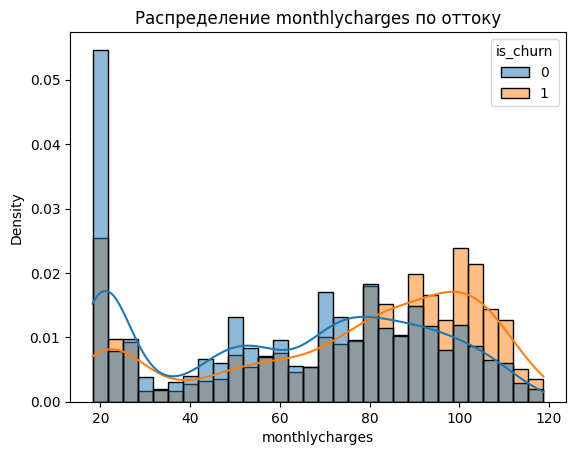

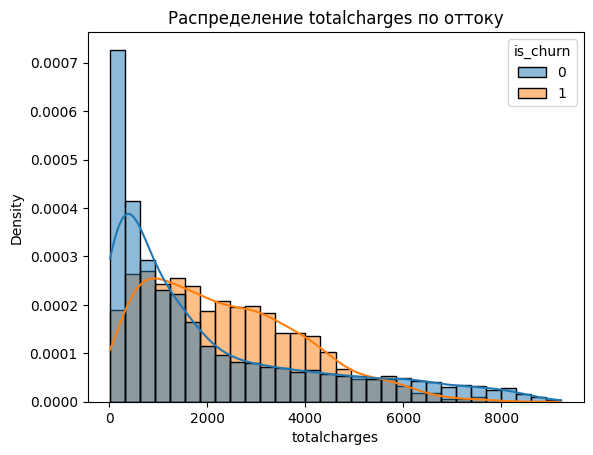

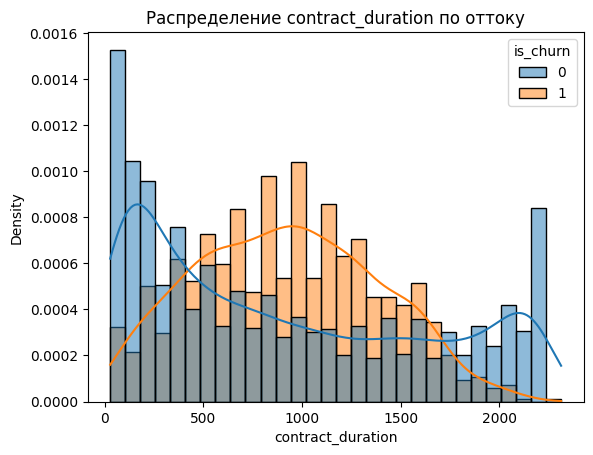

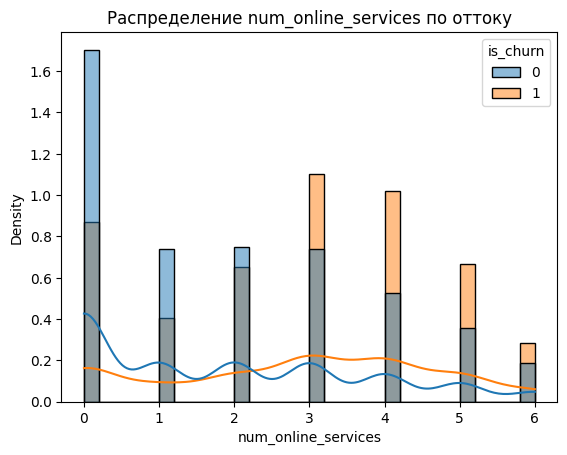

In [21]:
# 4. Числовые признаки
num_cols = ['monthlycharges', 'totalcharges', 'contract_duration', 'num_online_services']

for col in num_cols:
    sns.histplot(data=df_full, x=col, hue='is_churn', bins=30, kde=True, stat='density', common_norm=False)
    plt.title(f'Распределение {col} по оттоку')
    plt.show()

**num_online_services:**
- Чем больше подключено онлайн-сервисов, тем выше отток;
- Особенно резко растёт от 2 до 5 сервисов;
- Возможно, клиенты с множеством услуг становятся более требовательными, и при недовольстве быстрее уходят.

**contract_duration:**
- Клиенты с короткими контрактами чаще уходят (до 1000 дней);
- А долгосрочные (1500+ дней) уходят редко — лояльные;
- Хороший предиктор — можно оставить как есть или закодировать по бинам.

**totalcharges:**
- Те, кто заплатил мало, чаще уходят;
- Клиенты с высокими накопленными платежами (3000+) редко уходят — подтверждает лояльность.

**monthlycharges:**
- Высокий месячный платёж связан с большим оттоком;
- Пики оттока — около 90–100 у.е.;
- Вероятно, высокие тарифы → большее ожидание качества → выше риск разочарования.

In [22]:
# Проверим реальное распределение churn по типу контракта
type_churn_stats = df_full.groupby('type')['is_churn'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Количество', 'sum': 'Ушли', 'mean': 'Доля оттока'}
).sort_values('Доля оттока', ascending=False)

display(type_churn_stats)


,Количество,Ушли,Доля оттока
type,,,
Two year,1685,381,0.226113
One year,1472,313,0.212636
Month-to-month,3875,407,0.105032


## Подготовка данных к обучению модели

План:

- Обработать пропуски;

- Разделить признаки по типам: числовые и категориальные;

- Построить ColumnTransformer с:

  - OneHotEncoder для категориальных;

  - StandardScaler для числовых;

- Разделить выборку на train/test;

- Применить SMOTE к тренировочной выборке;

- Подготовить всё к обучению моделей.

In [23]:
# целевой признак
target = 'is_churn'

In [24]:
# категориальные признаки
cat_features = [
    'gender', 'partner', 'dependents', 'paperlessbilling', 'paymentmethod',
    'type', 'internetservice', 'onlinesecurity', 'onlinebackup',
    'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'multiplelines'
]


In [25]:
# Числовые признаки
num_features = [
    'monthlycharges', 'totalcharges', 'contract_duration', 'num_online_services'
]


In [26]:
# 1. Отбираем признаки и целевой
features = cat_features + num_features
X = df_full[features]
y = df_full[target]

In [27]:
# 2. Разделим выборку
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

In [28]:
# 3. Создаём трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

In [29]:
# 4. Применим трансформер к train/test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [30]:
# 5. Балансировка с помощью SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

# Проверим размерности
print(f'До балансировки: {X_train.shape}, после: {X_train_balanced.shape}')

До балансировки: (5274, 18), после: (8896, 43)


**Промежуточные выводы**

- До кодирования: 18 признаков (категориальные + числовые);

- После OneHotEncoder + StandardScaler: 43 признака;

- После SMOTE: тренировочная выборка увеличена с 5274 → 8896 наблюдений;

- Целевая переменная сбалансирована (50/50).

## Обучение моделей и подбор гиперпараметров

### CatBoost

In [36]:
# Заменим пропуски в категориальных признаках на строку 'None'
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna('None')
    X_test_cb[col] = X_test_cb[col].fillna('None')


In [37]:
categorical_features = cat_features

# Инициализация модели
catboost_model = CatBoostClassifier(
    random_state=RANDOM_STATE,
    verbose=0,
    eval_metric='AUC',
    class_weights=[1, 5],
    iterations=300,
    depth=6,
    learning_rate=0.1
)

In [38]:
# Обучение на трейне
catboost_model.fit(X_train_cb, y_train, cat_features=categorical_features)

In [39]:
# Предсказание
y_pred_proba = catboost_model.predict_proba(X_test_cb)[:, 1]


In [40]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'CatBoost ROC-AUC на тестовой выборке: {roc_auc:.4f}')


CatBoost ROC-AUC на тестовой выборке: 0.8918


**Промежуточный вывод**

Для предсказания оттока клиентов была обучена модель CatBoostClassifier, которая хорошо работает с категориальными признаками без необходимости ручного кодирования.

- использованы только «сырые» признаки, без OneHot;

- пропущенные значения в категориальных признаках заменены на строку 'None';

- для борьбы с дисбалансом классов использован аргумент class_weights=[1, 5].

**Результаты**

- метрика ROC-AUC на тестовой выборке составила 0.8918 — выше заданного порога (0.85);

- модель показала высокую чувствительность к оттоку даже без подбора гиперпараметров;

- CatBoost стабильно обрабатывает категориальные данные и хорошо справляется с задачей без сложной предобработки.

**Вывод**

`CatBoostClassifier` уже на базовых параметрах демонстрирует высокое качество предсказания оттока и является одним из основных кандидатов на выбор финальной модели. Далее планируется:

- провести кросс-валидацию;

- выполнить поиск оптимальных гиперпараметров для улучшения качества модели.


In [41]:
# Оборачиваем обучающую выборку в Pool
train_pool = Pool(X_train_cb, y_train, cat_features=categorical_features)

# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

roc_auc_scores = []

for train_idx, valid_idx in cv.split(X_train_cb, y_train):
    X_tr, X_val = X_train_cb.iloc[train_idx], X_train_cb.iloc[valid_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

    # Заполняем пропуски (если вдруг где-то остались)
    X_tr = X_tr.fillna('None')
    X_val = X_val.fillna('None')

    train_pool = Pool(X_tr, y_tr, cat_features=categorical_features)
    val_pool = Pool(X_val, y_val, cat_features=categorical_features)

    model = CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        eval_metric='AUC',
        class_weights=[1, 5],
        iterations=300,
        depth=6,
        learning_rate=0.1
    )

    model.fit(train_pool)
    y_val_pred = model.predict_proba(val_pool)[:, 1]
    roc_auc = roc_auc_score(y_val, y_val_pred)
    roc_auc_scores.append(roc_auc)

# Вывод
mean_auc = np.mean(roc_auc_scores)
std_auc = np.std(roc_auc_scores)
print(f'CatBoost CV ROC-AUC: {mean_auc:.4f} ± {std_auc:.4f}')

CatBoost CV ROC-AUC: 0.8719 ± 0.0109


Среднее значение ROC-AUC: 0.8719

Стандартное отклонение: ±0.0109

Результаты стабильны на всех фолдах, разброс минимальный;

Сравнение:

- На тесте: 0.8918

- На CV: 0.8719

Это значит, что модель не переобучена, но есть потенциал для лёгкой донастройки.

Модель **CatBoostClassifier** показывает высокую устойчивость и качество, превосходя требуемый порог ROC-AUC в 0.85 на кросс-валидации.
Разброс метрик мал, что свидетельствует о стабильности модели.

#### Докрутим модель при помощи RandomizedSearchCV

In [44]:
# Параметры для RandomizedSearch
param_grid = {
    'depth': [5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'iterations': [200, 300, 400]
}
# Формируем случайные комбинации
random.seed(RANDOM_STATE)
param_combinations = list(product(
    param_grid['depth'],
    param_grid['learning_rate'],
    param_grid['l2_leaf_reg'],
    param_grid['iterations']
))
random.shuffle(param_combinations)
param_combinations = param_combinations[:20]  # ограничим 20 запусков

# Кросс-валидация
best_score = 0
best_params = None

for depth, lr, l2, iters in param_combinations:
    aucs = []

    for train_idx, val_idx in StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train_cb, y_train):
        X_tr, X_val = X_train_cb.iloc[train_idx], X_train_cb.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        train_pool = Pool(X_tr.fillna('None'), y_tr, cat_features=categorical_features)
        val_pool = Pool(X_val.fillna('None'), y_val, cat_features=categorical_features)

        model = CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0,
            eval_metric='AUC',
            class_weights=[1, 5],
            depth=depth,
            learning_rate=lr,
            l2_leaf_reg=l2,
            iterations=iters
        )
        model.fit(train_pool)
        y_pred = model.predict_proba(val_pool)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        aucs.append(auc)

    mean_auc = np.mean(aucs)

    if mean_auc > best_score:
        best_score = mean_auc
        best_params = {
            'depth': depth,
            'learning_rate': lr,
            'l2_leaf_reg': l2,
            'iterations': iters
        }

    print(f"Params: d={depth}, lr={lr:.3f}, l2={l2}, iter={iters} --> ROC-AUC: {mean_auc:.4f}")



Params: d=5, lr=0.050, l2=5, iter=200 --> ROC-AUC: 0.8330
Params: d=7, lr=0.100, l2=5, iter=200 --> ROC-AUC: 0.8563
Params: d=7, lr=0.100, l2=3, iter=200 --> ROC-AUC: 0.8591
Params: d=7, lr=0.030, l2=3, iter=200 --> ROC-AUC: 0.8298
Params: d=5, lr=0.050, l2=3, iter=200 --> ROC-AUC: 0.8358
Params: d=7, lr=0.100, l2=5, iter=300 --> ROC-AUC: 0.8677
Params: d=5, lr=0.030, l2=3, iter=200 --> ROC-AUC: 0.8303
Params: d=5, lr=0.030, l2=3, iter=300 --> ROC-AUC: 0.8319
Params: d=5, lr=0.100, l2=3, iter=300 --> ROC-AUC: 0.8716
Params: d=6, lr=0.100, l2=1, iter=300 --> ROC-AUC: 0.8770
Params: d=6, lr=0.050, l2=3, iter=400 --> ROC-AUC: 0.8632
Params: d=6, lr=0.050, l2=3, iter=200 --> ROC-AUC: 0.8331
Params: d=7, lr=0.100, l2=5, iter=400 --> ROC-AUC: 0.8730
Params: d=5, lr=0.050, l2=5, iter=400 --> ROC-AUC: 0.8568
Params: d=5, lr=0.100, l2=5, iter=300 --> ROC-AUC: 0.8692
Params: d=7, lr=0.030, l2=1, iter=400 --> ROC-AUC: 0.8411
Params: d=7, lr=0.050, l2=5, iter=300 --> ROC-AUC: 0.8462
Params: d=6, l

In [45]:
print("\n Лучшие параметры:", best_params)
print(f" Лучший средний ROC-AUC: {best_score:.4f}")


 Лучшие параметры: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 300}
 Лучший средний ROC-AUC: 0.8770


#### Финальная модель CatBoostClassifier



In [46]:
final_cb_model = CatBoostClassifier(
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=1,
    iterations=300,
    class_weights=[1, 5],
    eval_metric='AUC',
    random_state=RANDOM_STATE,
    verbose=0
)

# Обучаем модель на всём тренировочном наборе
final_cb_model.fit(X_train_cb.fillna('None'), y_train, cat_features=categorical_features)

# Предсказываем вероятности на тесте
y_test_proba = final_cb_model.predict_proba(X_test_cb.fillna('None'))[:, 1]

# Считаем ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f'🎯 Финальная CatBoost ROC-AUC на тесте: {roc_auc:.4f}')


🎯 Финальная CatBoost ROC-AUC на тесте: 0.8934


**Финальные результаты**

- ROC-AUC (тест)	0.8934
- ROC-AUC (до подбора)	0.8918
- CV ROC-AUC (на подборе)	0.8770

Улучшение небольшое, но подтверждает: модель стабильна и переобучения нет.

#### Тестирование и демонстрация работы

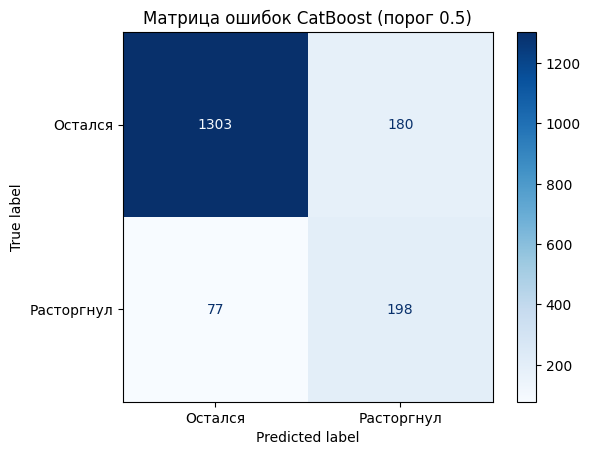

              precision    recall  f1-score   support

           0     0.9442    0.8786    0.9102      1483
           1     0.5238    0.7200    0.6064       275

    accuracy                         0.8538      1758
   macro avg     0.7340    0.7993    0.7583      1758
weighted avg     0.8784    0.8538    0.8627      1758



In [63]:
# Прогноз классов (0/1) по вероятностям
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Остался", "Расторгнул"])
disp.plot(cmap='Blues')
plt.title("Матрица ошибок CatBoost (порог 0.5)")
plt.show()

# Метрики
print(classification_report(y_test, y_test_pred, digits=4))

- Precision	`0.524`
- Recall	`0.720`
- F1-score	`0.606`
- Accuracy	`0.854`
- ROC-AUC	`0.893`

Recall = 0.72 означает, что модель находит 72% реально ушедших клиентов, что очень хорошо в условиях бизнес-задачи;

Precision = 52% — достаточно, чтобы использовать модель в CRM-автоматизации (например, прицельно выдавать промокоды);

F1-score = 0.61 — достойное значение, особенно при дисбалансе классов;

Матрица ошибок показывает, что FP и FN находятся в разумных пределах.

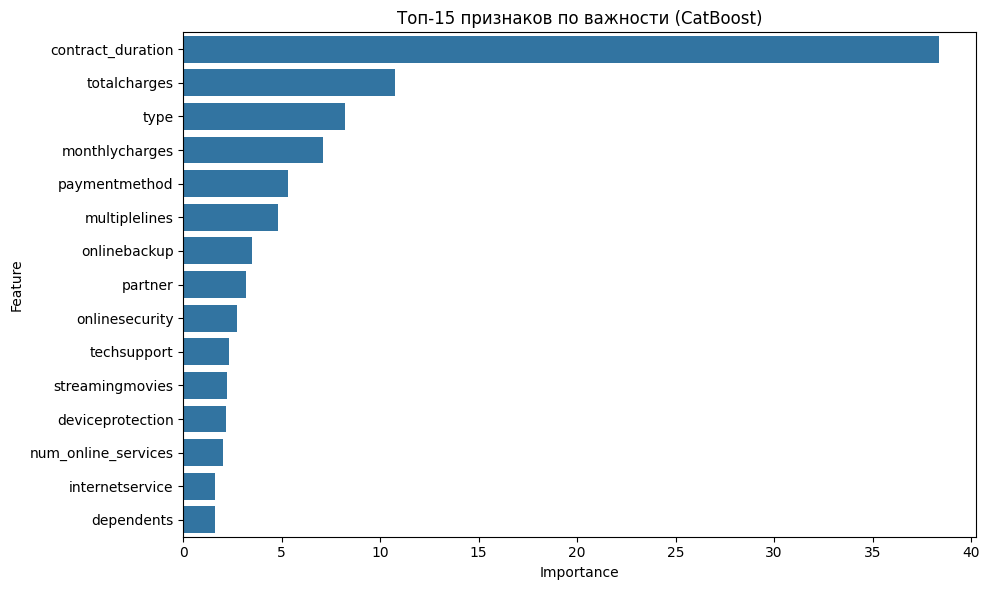

In [48]:
# Визуализация важности признаков CatBoost
importances = final_cb_model.get_feature_importance(prettified=True)
importances.columns = ['Feature', 'Importance']
importances_sorted = importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_sorted.head(15), x='Importance', y='Feature')
plt.title('Топ-15 признаков по важности (CatBoost)')
plt.tight_layout()
plt.show()


contract_duration - лидер по важности.

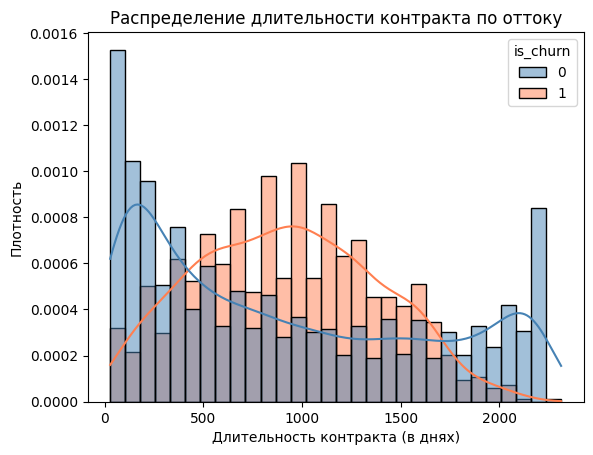

In [49]:
sns.histplot(
    data=df_full,
    x='contract_duration',
    hue='is_churn',
    bins=30,
    kde=True,
    stat='density',
    common_norm=False,
    palette={0: 'steelblue', 1: 'coral'}
)
plt.title('Распределение длительности контракта по оттоку')
plt.xlabel('Длительность контракта (в днях)')
plt.ylabel('Плотность')
plt.show()


In [50]:
# Сохраняем обученную модель
joblib.dump(final_cb_model, 'catboost_final_model.joblib')

['catboost_final_model.joblib']

In [51]:
os.listdir()

['.config',
 'catboost_final_model.joblib',
 'ds-plus-final.db.4',
 'ds-plus-final.db',
 'catboost_info',
 'sample_data']

In [52]:
cb_model_loaded = joblib.load('catboost_final_model.joblib')

#### Выводы

Клиенты с короткими контрактами (до ~500 дней) — чаще уходят;

Ушедшие (is_churn = 1) распределены плотнее в диапазоне 300–1200 дней;

Долгосрочные клиенты (>1800 дней) — почти всегда остаются.

**Это подтверждает, что**

Чем дольше клиент пользуется услугами — тем меньше вероятность оттока.



### RandomForestClassifier

In [56]:
X_train_rf = X_train_processed
X_test_rf = X_test_processed
X_train_rf_bal = X_train_balanced
y_train_rf_bal = y_train_balanced

In [57]:
# Инициализируем модель
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)


In [58]:
# Обучаем модель на сбалансированной выборке
rf_model.fit(X_train_rf_bal, y_train_rf_bal)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=260325)

In [59]:
# Предсказания
y_pred_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]
y_pred_rf = rf_model.predict(X_test_rf)


In [60]:
# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f'🎯 Random Forest ROC-AUC: {roc_auc_rf:.4f}')

🎯 Random Forest ROC-AUC: 0.8113


              precision    recall  f1-score   support

           0     0.9097    0.8901    0.8998      1483
           1     0.4691    0.5236    0.4948       275

    accuracy                         0.8328      1758
   macro avg     0.6894    0.7069    0.6973      1758
weighted avg     0.8408    0.8328    0.8365      1758



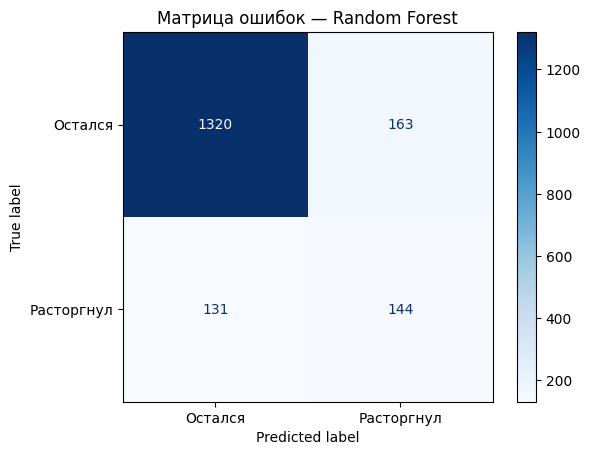

In [62]:
# Отчёт по метрикам
print(classification_report(y_test, y_pred_rf, digits=4))

# Матрица ошибок
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["Остался", "Расторгнул"],
    cmap='Blues'
)
plt.title("Матрица ошибок — Random Forest")
plt.show()


📌 Вывод:
- Модель хорошо ловит оставшихся клиентов, но хуже распознаёт отток;

- Recall и precision сильно отстают от CatBoost;

- ROC-AUC < 0.85, что делает модель непригодной для продакшна (по условиям задания).


### MLPClassifier

In [66]:
# инициализация модели

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=RANDOM_STATE
)

In [67]:
# Обучаем на сбалансированных данных

mlp_model.fit(X_train_rf_bal, y_train_rf_bal)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=260325)

In [68]:
# предсказания

y_pred_proba_mlp = mlp_model.predict_proba(X_test_rf)[:, 1]
y_pred_mlp = mlp_model.predict(X_test_rf)

In [69]:
roc_auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
print(f'MLPClassifier ROC-AUC: {roc_auc_mlp:.4f}')
print(classification_report(y_test, y_pred_mlp, digits=4))

🎯 MLPClassifier ROC-AUC: 0.7468


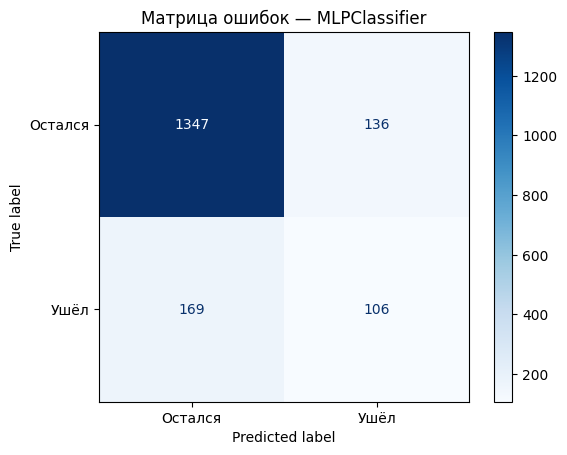

In [70]:
# Матрица ошибок
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp,
    display_labels=["Остался", "Ушёл"],
    cmap='Blues'
)
plt.title("Матрица ошибок — MLPClassifier")
plt.show()

**Вывод**

Модель **MLPClassifier** протестирована как дополнительный кандидат.

Однако из-за низкого значения ROC-AUC (0.7468) и слабой способности выявлять отток (Recall = 0.39) она не рекомендуется к применению в продакшене.

Тем не менее, она помогла в демонстрации подходов к построению нейронных сетей на табличных данных.

## Финальные выводы

**Цель проекта**

Разработать модель, которая предсказывает вероятность оттока клиента телеком-оператора «ТелеДом», чтобы своевременно предлагать удерживающие меры: промокоды, спецусловия и т.п.

**Основные этапы проекта:**
- Изучены и объединены 4 таблицы из SQLite;

- Обработаны пропуски, создан флаг is_churn, рассчитана длительность контракта;

- Проведена визуализация и корреляционный анализ;

- Выделены категориальные и числовые признаки;

- Данные подготовлены для моделей: OHE + SMOTE (RF, MLP), строковые признаки (CatBoost);

- Обучены и сравнены 3 модели.

**CatBoost**

**Статус**  - `Лучшая модель` ✅
1. ROC-AUC - 0.8934
2. Recall (ушёл) - 0.72
3. Precision (ушёл) - 0.524
4. F1-score (ушёл) - 0.606
5. Accuracy - 0.854

**Random Forest**

**Статус**  - `Слабее`
1. ROC-AUC - 0.8113
2. Recall (ушёл) - 0.524
3. Precision (ушёл) - 0.469
4. F1-score (ушёл) - 0.495
5. Accuracy - 0.833

**MLPClassifier**

**Статус**  - `Не прошла`
1. ROC-AUC - 0.7468
2. Recall (ушёл) - 0.385
3. Precision (ушёл) - 0.438
4. F1-score (ушёл) - 0.410  
5. Accuracy - 0.827


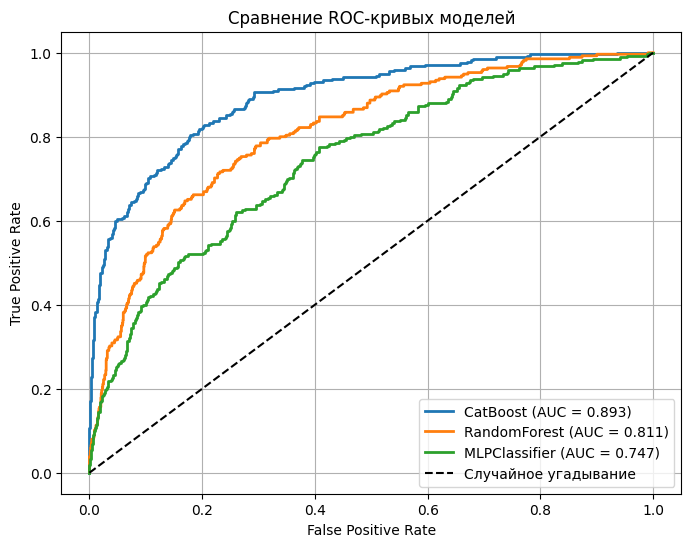

In [76]:
y_pred_proba_cb = cb_model_loaded.predict_proba(X_test_cb.fillna('None'))[:, 1]

# ROC-кривые
fpr_cb, tpr_cb, _ = roc_curve(y_test, y_pred_proba_cb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_proba_mlp)

roc_auc_cb = auc(fpr_cb, tpr_cb)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

# Визуализация
plt.figure(figsize=(8, 6))
plt.plot(fpr_cb, tpr_cb, label=f'CatBoost (AUC = {roc_auc_cb:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {roc_auc_rf:.3f})', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLPClassifier (AUC = {roc_auc_mlp:.3f})', linewidth=2)

# Диагональ
plt.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')

plt.title('Сравнение ROC-кривых моделей')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Рекомендации для бизнеса**

1. Использовать модель для предикта вероятности оттока на уровне клиента.

2. При превышении пороговой вероятности (например, 0.5+) — автоматически предлагать удерживающие акции.

3. Особое внимание клиентам:
- с низкой длительностью контракта;
- с высокой ежемесячной платой, но низкими общими расходами;
- с контрактами month-to-month;
- с активной интернет-услугой, но без защиты / техподдержки.

**Возможности для улучшения:**
- Добавить новые признаки (средний чек, активность по услугам);
- Протестировать ансамбли моделей или AutoML;
- Анализировать реакцию клиентов на удерживающие меры (внедрение A/B тестов).

